# ChangeViT Inference — GitHub `best_model.pth` 사용

**전제조건**: 이 노트북은 `ChangeViT` GitHub repo root dir에서 실행.
```
ChangeViT/
├── model/
│   ├── trainer.py   ← Trainer 클래스 (encoder + decoder)
│   ├── encoder.py
│   ├── decoder.py
│   └── resnet.py
├── checkpoint/
│   └── dinov2_vits14_pretrain.pth  ← 훈련 때 사용한 ViT 체크포인트
├── best_model.pth   ← 훈련으로 얻은 최종 모델
└── [this notebook]
```

> `best_model.pth`는 GitHub `Trainer` (= encoder + decoder) 의 `state_dict`,  
> `Trainer`를 그대로 재구성하고 weights 만 로드.  
> torchgeo / Lightning 불필요.  

## 1. Load Trained Model

> **Core Mechanism**: `Trainer(model_type='small')` 을 생성한 뒤 `best_model.pth` 를 `load_state_dict` 로 로드.  
> `Trainer.__init__` 내부에서 `Encoder` 가 `dinov2_vits14_pretrain.pth` 를 로드하지만,  
> 이후 `load_state_dict` 가 덮어쓰므로 **훈련된 weights** 가 최종적으로 적용.

In [ ]:
from pathlib import Path
import sys
import torch
from model.trainer import Trainer  # GitHub 소스 import

DATA_ROOT   = Path("D:/Project-Dataset/LEVIR-CD-256")   # 데이터셋 
SPLIT       = "test"                                    # "test" or "val"
CKPT_PATH   = Path("./results_LEVIR_iter_80000_lr_0.0002/best_model.pth") # 훈련된 모델 경로
IMG_SIZE    = 256
THRESHOLD   = 0.5
MODEL_TYPE  = 'small'                                   # 'small' or 'tiny'

# ChangeViT repo root가 sys.path 에 없는 경우
repo_root = Path(".").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 모델 생성 ─────────────────────────────────────────────
model = Trainer(model_type=MODEL_TYPE)

# ── state_dict 로드 ───────────────────────────────────────
state_dict = torch.load(CKPT_PATH, map_location=DEVICE)

# 저장 방식에 따라 key 구조가 다를 수 있으므로 두 경우 모두 처리
if "state_dict" in state_dict:          # Lightning checkpoint 형식인 경우
    raw = state_dict["state_dict"]
    # LightningModel 은 self.model 에 Trainer 를 담았으므로 'model.' prefix 제거
    state_dict = {k.replace("model.", "", 1): v
                  for k, v in raw.items() if k.startswith("model.")}
# else: 순수 state_dict (GitHub eval.py 저장 방식)

msg = model.load_state_dict(state_dict, strict=True)
print("load_state_dict:", msg)

model.eval().to(DEVICE)
print("모델 로드 완료 ✅")

d:\Project-CD\ChangeViT\model\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
d:\Project-CD\ChangeViT\model\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
d:\Project-CD\ChangeViT\model\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Device: cuda
using MLP layer as FFN
 missing_keys:['pos_embed', 'patch_embed.proj.weight'],
 unexpected_keys:['cls_token', 'blocks.0.ls1.gamma', 'blocks.0.ls2.gamma', 'blocks.1.ls1.gamma', 'blocks.1.ls2.gamma', 'blocks.2.ls1.gamma', 'blocks.2.ls2.gamma', 'blocks.3.ls1.gamma', 'blocks.3.ls2.gamma', 'blocks.4.ls1.gamma', 'blocks.4.ls2.gamma', 'blocks.5.ls1.gamma', 'blocks.5.ls2.gamma', 'blocks.6.ls1.gamma', 'blocks.6.ls2.gamma', 'blocks.7.ls1.gamma', 'blocks.7.ls2.gamma', 'blocks.8.ls1.gamma', 'blocks.8.ls2.gamma', 'blocks.9.ls1.gamma', 'blocks.9.ls2.gamma', 'blocks.10.ls1.gamma', 'blocks.10.ls2.gamma', 'blocks.11.ls1.gamma', 'blocks.11.ls2.gamma']
model_type: small,
 checkpoint_path: checkpoint/dinov2_vits14_pretrain.pth
initialize: c2_c5
initialize: c3_c5
initialize: c4_c5
initialize: fuse
initialize: structure_enhance
initialize: up_c5
initialize: 0
initialize: 1
initialize: up_c4
initialize: 0
initialize: 1
initialize: up_c3
initialize: 0
initialize: 1
initialize: classfier
initializ

> **`strict=True` 로 오류가 나는 경우**  
> `strict=False` 로 바꾸고 `missing_keys` / `unexpected_keys` 를 확인 필요.  
> Lightning `.ckpt` 저장 방식이면 위의 'model.' prefix 제거 로직이 적용.

## 2. Preprocess: Transform

In [2]:
import numpy as np
from PIL import Image
from torchvision import transforms
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """[3,H,W] normalized tensor → [H,W,3] uint8 numpy for display"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = tensor.cpu() * std + mean
    img  = img.clamp(0, 1).permute(1,2,0).numpy()
    return (img * 255).astype(np.uint8)

## 3. Inference ftn for a single sample

> **GitHub `Trainer.forward(self, x, y)`** 는 x, y 를 **분리**해서 받습니다.  
> 기존 torchgeo 버전의 `model.model(image)` ([1,2,3,H,W]) 와 달리,  
> `model(t_a, t_b)` 형태로 호출합니다.

In [ ]:
@torch.no_grad()
def run_inference(fname: str) -> dict:
    dir_a     = DATA_ROOT / SPLIT / "A"
    dir_b     = DATA_ROOT / SPLIT / "B"
    dir_label = DATA_ROOT / SPLIT / "label"

    img_a = Image.open(dir_a     / fname).convert("RGB")
    img_b = Image.open(dir_b     / fname).convert("RGB")
    mask  = Image.open(dir_label / fname).convert("L")

    t_a = img_transform(img_a)                        # [3, H, W]
    t_b = img_transform(img_b)                        # [3, H, W]

    # GitHub Trainer: forward(x, y) — 각각 [B, 3, H, W]
    x = t_a.unsqueeze(0).to(DEVICE)                   # [1, 3, H, W]
    y = t_b.unsqueeze(0).to(DEVICE)                   # [1, 3, H, W]

    prob = model(x, y)                              # [1, 1, H, W]
    prob = prob.squeeze().cpu()
    # 주의 : trainer model에서 이미 sigmoid 적용
    # prob   = torch.sigmoid(logits).squeeze().cpu()    # [H, W]
    pred   = (prob > THRESHOLD).numpy().astype(np.uint8) # [H, W] bool

    # GT mask
    mask_np = np.array(mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
    gt = (mask_np > 127).astype(np.uint8)

    # Metrics 계산
    tp = ((pred == 1) & (gt == 1)).sum()
    fp = ((pred == 1) & (gt == 0)).sum()
    fn = ((pred == 0) & (gt == 1)).sum()
    precision = tp / (tp + fp + 1e-5)
    recall    = tp / (tp + fn + 1e-5)
    f1  = 2 * precision * recall / (precision + recall + 1e-5)
    iou = tp / (tp + fp + fn + 1e-5)

    return { "fname" : fname,
             "img_a" : denormalize(t_a),
             "img_b" : denormalize(t_b),
             "gt"    : gt,
             "pred"  : pred.astype(np.uint8),
             "prob"  : prob.numpy(),
             "f1"    : float(f1),
             "iou"   : float(iou), }

## 4. Inferenc on 5 Samples 

In [ ]:
# 5개 파일명 지정
SELECTED_FILES = [  "test_2_1.png",
                    "test_3_1.png",
                    "test_2_2.png",
                    "test_7_13.png",
                    "test_12_10.png", ]

results = [run_inference(f) for f in SELECTED_FILES]
for r in results:
    print(f"{r['fname']:20s}  F1={r['f1']:.4f}  IoU={r['iou']:.4f}")
print(f"\n{len(results)}개 추론 완료 ")

test_2_1.png          F1=0.9260  IoU=0.8622
test_3_1.png          F1=0.9484  IoU=0.9018
test_2_2.png          F1=0.9323  IoU=0.8731
test_7_13.png         F1=0.9152  IoU=0.8437
test_12_10.png        F1=0.8871  IoU=0.7970

5개 추론 완료 


## 5. Visualization

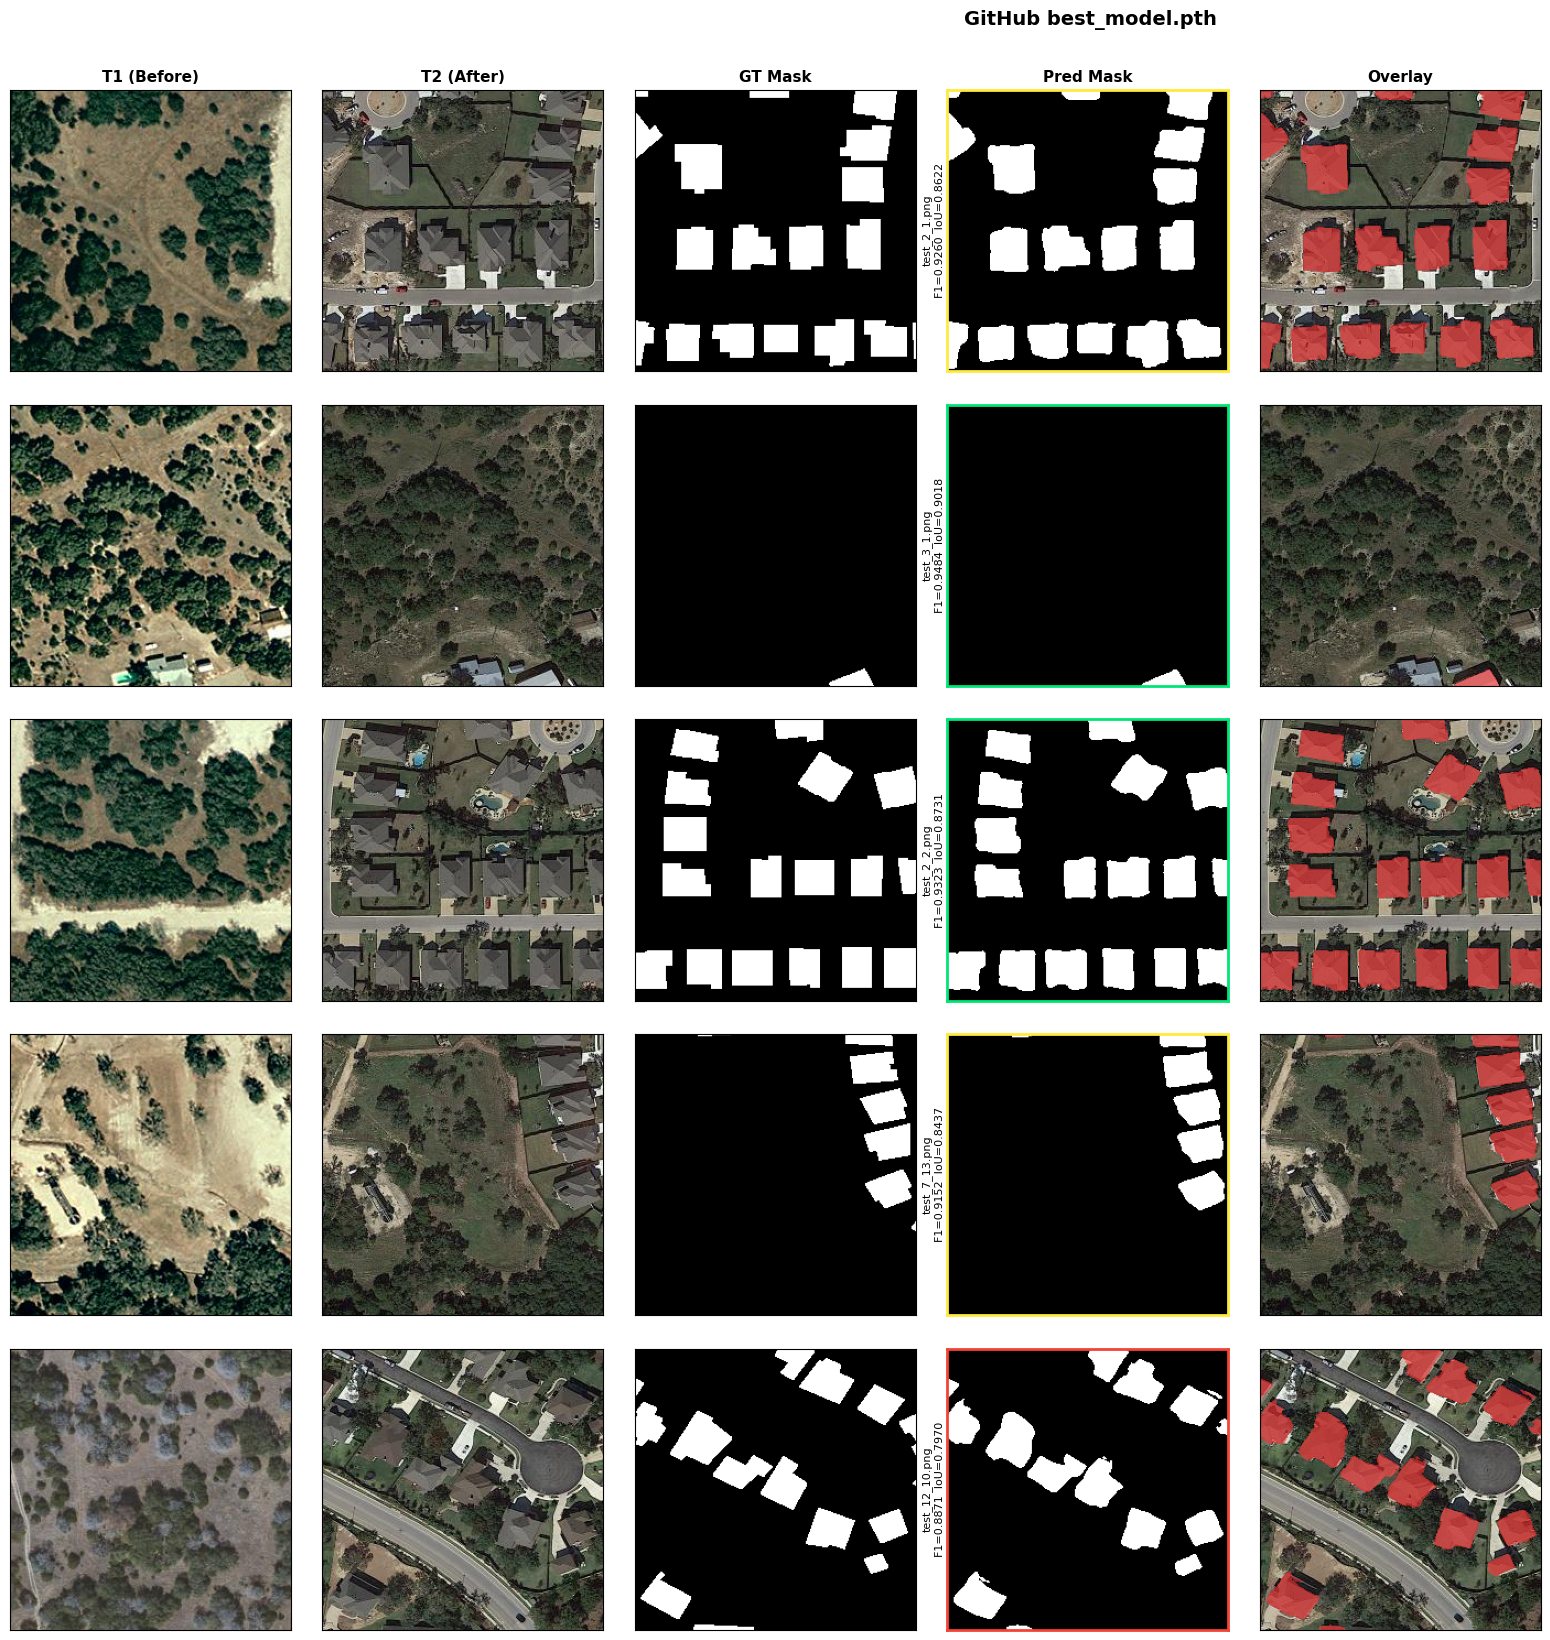

저장 완료: Inference_GitHub_results.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

COL_TITLES = ["T1 (Before)", "T2 (After)", "GT Mask", "Pred Mask", "Overlay"]
N = len(results)

fig = plt.figure(figsize=(20, 4 * N))
# fig.patch.set_facecolor("#0f0f0f")
outer = gridspec.GridSpec(N, 1, hspace=0.12, figure=fig)

for row_idx, r in enumerate(results):
    inner = gridspec.GridSpecFromSubplotSpec(
        1, 5, subplot_spec=outer[row_idx], wspace=0.04
    )

    # Overlay: T2 위에 pred 반투명 빨간색
    overlay = r["img_b"].copy()
    change_mask = r["pred"].astype(bool)
    overlay[change_mask] = (
        overlay[change_mask] * 0.4 +
        np.array([255, 50, 50]) * 0.6
    ).astype(np.uint8)

    images = [r["img_a"], r["img_b"], r["gt"], r["pred"], overlay]
    cmaps  = [None,        None,       "gray",  "gray",   None   ]

    for col_idx, (img, cmap) in enumerate(zip(images, cmaps)):
        ax = fig.add_subplot(inner[col_idx])
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1 if img.max() <= 1 else None)
        ax.set_xticks([]); ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx],
                         color='black', fontsize=11, pad=6, fontweight="bold")

        if col_idx == 3:
            label = (f"{r['fname']}\n"
                     f"F1={r['f1']:.4f}  IoU={r['iou']:.4f}")
            ax.set_ylabel(label, color='black', fontsize=8,
                          rotation=90, labelpad=10, va="center")

        if col_idx == 3:  # Pred 열: F1 기반 테두리 색
            color = ("#00e676" if r["f1"] >= 0.93 else
                     "#ffeb3b" if r["f1"] >= 0.90 else "#f44336")
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)

# plt.suptitle("ChangeViT — GitHub best_model.pth", 
#              color="black", fontsize=14, fontweight="bold", y=0.920)
plt.suptitle("GitHub best_model.pth", x=0.67,
             color="black", fontsize=14, fontweight="bold", y=0.920)
plt.savefig("Inference_GitHub_results.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("저장 완료: Inference_GitHub_results.png")

## 6. Complete test set F1 / IoU Evaluation

GitHub `eval.py` 와 동일한 방식으로 전체 test set 을 평가.

In [ ]:
from torch.utils.data import DataLoader, Dataset

class LEVIRTestDataset(Dataset):
    def __init__(self, root: Path, split: str = "test", img_size: int = 256):
        list_file = root / "list" / f"{split}.txt"
        with open(list_file) as f:
            self.filenames = [l.strip() for l in f if l.strip()]
        self.dir_a   = root / split / "A"
        self.dir_b   = root / split / "B"
        self.dir_lbl = root / split / "label"
        self.tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
        self.lbl_tf = transforms.Resize( (img_size, img_size),
            interpolation=transforms.InterpolationMode.NEAREST )

    def __len__(self): return len(self.filenames)

    def __getitem__(self, idx):
        fn = self.filenames[idx]
        a  = self.tf(Image.open(self.dir_a   / fn).convert("RGB"))
        b  = self.tf(Image.open(self.dir_b   / fn).convert("RGB"))
        m  = Image.open(self.dir_lbl / fn).convert("L")
        m  = (transforms.ToTensor()(self.lbl_tf(m)) > 0.5).long().squeeze(0)
        return a, b, m  # [3,H,W], [3,H,W], [H,W]

test_ds = LEVIRTestDataset(DATA_ROOT, split=SPLIT)
test_dl = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

total_tp = total_fp = total_fn = 0

model.eval()
with torch.no_grad():
    for a, b, gt in test_dl:
        a, b, gt = a.to(DEVICE), b.to(DEVICE), gt.to(DEVICE)
        prob = model(a, b)                             # [B,1,H,W]
        pred   = (prob > THRESHOLD).long().squeeze(1)  # [B,H,W]
        # 주의 : trainer model에서 이미 sigmoid 적용
        # pred   = (torch.sigmoid(logits) > THRESHOLD).long().squeeze(1)  # [B,H,W]
        total_tp += ((pred==1) & (gt==1)).sum().item()
        total_fp += ((pred==1) & (gt==0)).sum().item()
        total_fn += ((pred==0) & (gt==1)).sum().item()

precision = total_tp / (total_tp + total_fp + 1e-5)
recall    = total_tp / (total_tp + total_fn + 1e-5)
f1_total  = 2 * precision * recall / (precision + recall + 1e-5)
iou_total = total_tp / (total_tp + total_fp + total_fn + 1e-5)

print(f"\n{'='*40}")
print(f"Complete {SPLIT} set Evaluation")
print(f"  F1  : {f1_total:.4f}")
print(f"  IoU : {iou_total:.4f}")
print(f"  P   : {precision:.4f}")
print(f"  R   : {recall:.4f}")
print(f"{'='*40}")


전체 test set 평가 결과
  F1  : 0.9080
  IoU : 0.8315
  P   : 0.9073
  R   : 0.9087


---
## 📋 요약

| 항목 | torchgeo 버전 | GitHub `best_model.pth` 버전 |
|---|---|---|
| 모델 클래스 | `LightningModel` (torchgeo `ChangeViT` 내장) | `Trainer` (GitHub 소스 직접 import) |
| forward 호출 | `model.model(image)` — `[1,2,3,H,W]` | `model(x, y)` — 각각 `[B,3,H,W]` |
| 체크포인트 로드 | `load_from_checkpoint()` | `torch.load` + `load_state_dict` |
| 외부 의존성 | torchgeo, Lightning | GitHub 레포 소스만 |
